In [294]:
from typing import Callable
from IPython.display import Math, Markdown
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Нелинейные уравнения

##### Методы решения (1)

In [295]:
def newton(x0: float, f: Callable, df: Callable,
           tol=1e-6, max_iter=1000, history=None) -> float:
  """ Метод Ньютона решения нелинейных уравнений """
  x = x0

  if history is not None: history.append(x)

  for i in range(max_iter):

    if df(x) == 0: return 0

    x = x - f(x)/df(x)

    if history: history.append(x)

    if np.abs(f(x)) < tol:
      x = round(x, abs(int(np.log10(tol))))
      break

  return x

In [296]:
def tangent(x0: float, f: Callable, df: float|Callable,
            tol=1e-6, max_iter=1000, history=None) -> float:
  """ Метод одной касательной решения нелинейных уравнений """
  df_x0 = df(x0) if callable(df) else df

  if df_x0 == 0: raise ValueError("Производная в точке x0 равна 0!")

  x = x0

  if history is not None: history.append(x)

  for i in range(max_iter):
    x = x - f(x)/df_x0

    if history: history.append(x)

    if np.abs(f(x)) < tol:
      x = round(x, abs(int(np.log10(tol))))
      break

  return x

In [297]:
def secant(x0: float, x1: float, f: Callable,
           tol=1e-6, max_iter=1000, history=None) -> float:
  """ Метод секущих решения нелинейных уравнений """
  x_a, x_b = x0, x1

  if history is not None: history.extend([x0, x1])

  for i in range(max_iter):
    if (f(x_b) - f(x_a)) == 0: return 0

    x = x_b - f(x_b)*(x_b - x_a)/(f(x_b) - f(x_a))
    x_a, x_b = x_b, x

    if history: history.append(x)

    if np.abs(f(x)) < tol:
      x = round(x, abs(int(np.log10(tol))))
      break

  return x

- Метод **Ньютона** имеет ***квадратичную*** сходимость
- Метод **одной касательной** имеет ***линейную*** сходимость
- Метод **секущих** имеет ***сверхлинейную*** сходимость

##### Тестирование на функциях (2)

In [298]:
def experiment_test(formula, f, df, newton_x0, tangent_x0, secant_x0, secant_x1):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Метод Ньютона
    history = []
    x_newton = newton(newton_x0, f, df, history=history)
    x_axis = np.array(range(len(history)))
    y_axis = np.abs(f(np.array(history)))
    ax1.plot(x_axis, y_axis, marker='o', color='r')
    ax1.set_title("Метод Ньютона")
    ax1.set_ylabel("|f(x)|")
    ax1.set_xlabel("iteration")
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax1.grid(True)

    # Метод одной касательной
    history = []
    x_tangent = tangent(tangent_x0, f, df, history=history)
    x_axis = np.array(range(len(history)))
    y_axis = np.abs(f(np.array(history)))
    ax2.plot(x_axis, y_axis, marker='o', color='b')
    ax2.set_title("Метод одной касательной")
    ax2.set_ylabel("|f(x)|")
    ax2.set_xlabel("iteration")
    ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.grid(True)

    # Метод секущих
    history = []
    x_secant = secant(secant_x0, secant_x1, f, history=history)
    x_axis = np.array(range(len(history)))
    y_axis = np.abs(f(np.array(history)))
    ax3.plot(x_axis, y_axis, marker='o', color='g')
    ax3.set_title("Метод секущих")
    ax3.set_ylabel("|f(x)|")
    ax3.set_xlabel("iteration")
    ax3.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax3.grid(True)

    display(Math(f'x_N \\approx {x_newton}'))
    display(Math(f'x_T \\approx {x_tangent}'))
    display(Math(f'x_S \\approx {x_secant}'))

    plt.suptitle(formula)
    plt.tight_layout()
    plt.show()

##### Чувствительность к начальному приближению (3)

In [299]:
def experiment_start(formula, f, df, newton_x0_range, tangent_x0_range,
                secant_x0_range, secant_x1, secant_x0, secant_x1_range):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

    # Метод Ньютона
    newton_iters = []
    for x0 in newton_x0_range:
        history = []
        newton(x0, f, df, tol=1e-10, history=history)
        newton_iters.append(len(history))

    ax1.plot(newton_x0_range, newton_iters, 'ro-', markersize=4)
    ax1.set_title("Метод Ньютона")
    ax1.set_xlabel("x0")
    ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax1.set_ylabel("Число итераций")
    ax1.grid(True)

    # Метод касательной
    tangent_iters = []
    for x0 in tangent_x0_range:
        history = []
        tangent(x0, f, df, tol=1e-10, history=history)
        tangent_iters.append(len(history))

    ax2.plot(tangent_x0_range, tangent_iters, 'bo-', markersize=4)
    ax2.set_title("Метод Касательной")
    ax2.set_xlabel("x0")
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.set_ylabel("Число итераций")
    ax2.grid(True)

    # Метод cекущих - зависимость от первого
    secant_iters_x0 = []
    for x0 in secant_x0_range:
        history = []
        secant(x0, secant_x1, f, tol=1e-10, history=history)
        secant_iters_x0.append(len(history))

    ax3.plot(secant_x0_range, secant_iters_x0, 'go-', markersize=4)
    ax3.set_title("Метод Секущих (зависимость от x0)")
    ax3.set_xlabel("x0")
    ax3.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax3.set_ylabel("Число итераций")
    ax3.grid(True)

    # Метод cекущих - зависимость от второго
    secant_iters_x1 = []
    for x1 in secant_x1_range:
        history = []
        secant(secant_x0, x1, f, tol=1e-10, history=history)
        secant_iters_x1.append(len(history))

    ax4.plot(secant_x1_range, secant_iters_x1, 'yo-', markersize=4)
    ax4.set_title("Метод Секущих (зависимость от x1)")
    ax4.set_xlabel("x1")
    ax4.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax4.set_ylabel("Число итераций")
    ax4.grid(True)


    plt.suptitle(f"Сравнение методов для {formula}")
    plt.tight_layout()
    plt.show()

##### Считаем производные

In [300]:
def derivative(f):
  """ Символьно вычисляет производную """
  df = sp.Derivative(f, x)
  display(sp.Eq(df, df.doit(), evaluate=False))

In [301]:
x = sp.symbols('x')
derivative(x**2 - 2)
derivative(sp.cos(x)  - x)
derivative(sp.exp(-x) - x)

Eq(Derivative(x**2 - 2, x), 2*x)

Eq(Derivative(-x + cos(x), x), -sin(x) - 1)

Eq(Derivative(-x + exp(-x), x), -1 - exp(-x))

##### $f(x) = x^2 - 2$

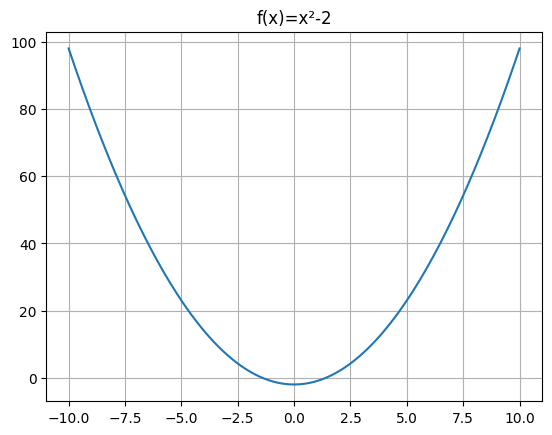

In [302]:
x = np.linspace(-10, 10, 200)
f = lambda x: x**2 - 2
plt.plot(x, f(x))
plt.title("f(x)=x²-2")
plt.grid(True)
plt.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

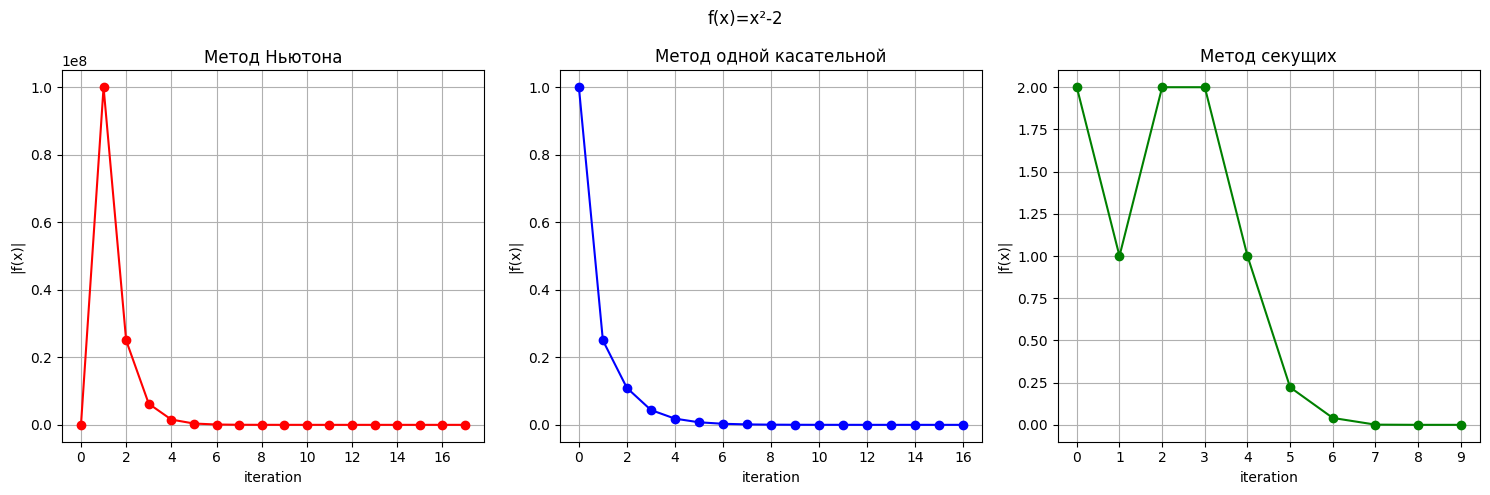

In [303]:
experiment_test(
    formula="f(x)=x²-2",
    f = lambda x: x**2 - 2,
    df = lambda x: 2*x,
    newton_x0 = 1e-4,
    tangent_x0 = -1,
    secant_x0 = -2,
    secant_x1 = 1
)

/tmp/ipython-input-1586228330.py:3: RuntimeWarning: overflow encountered in scalar power
  f = lambda x: x**2 - 2,


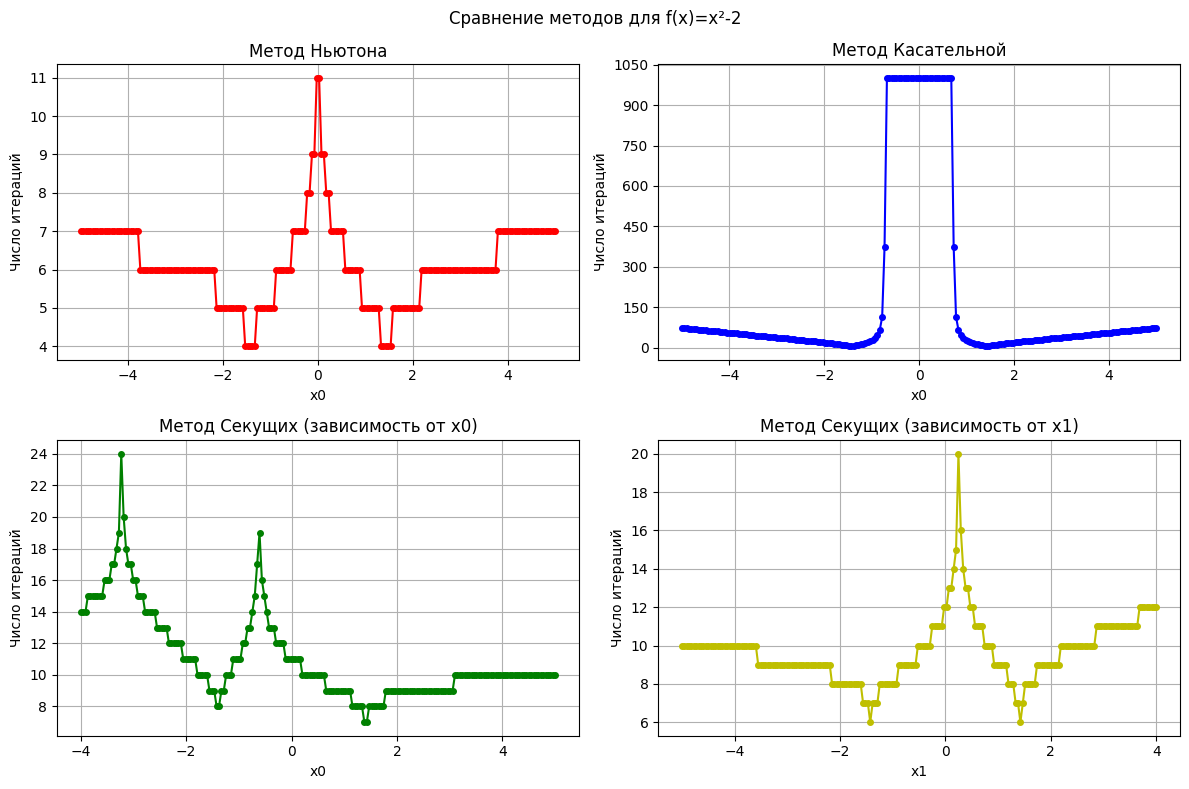

In [304]:
experiment_start(
    formula="f(x)=x²-2",
    f = lambda x: x**2 - 2,
    df = lambda x: 2*x,
    newton_x0_range = np.linspace(-5, 5, 200),
    tangent_x0_range = np.linspace(-5, 5, 200),
    secant_x0_range = np.linspace(-4, 4.999, 200),
    secant_x1 = 5,
    secant_x0 = -5,
    secant_x1_range = np.linspace(-4.999, 4, 200)
)

##### $f(x) = \cos{x} - x$

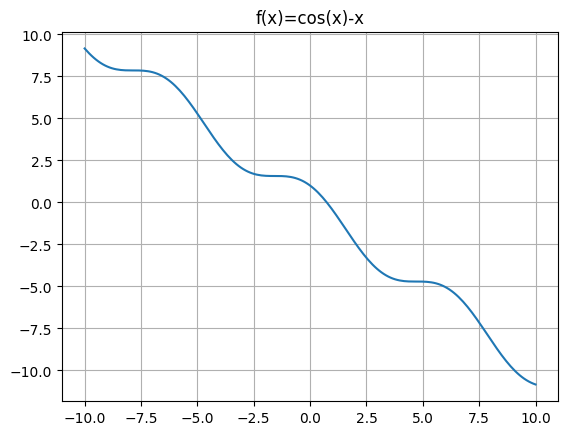

In [305]:
x = np.linspace(-10, 10, 200)
f = lambda x: np.cos(x) - x
plt.plot(x, f(x))
plt.title("f(x)=cos(x)-x")
plt.grid(True)
plt.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

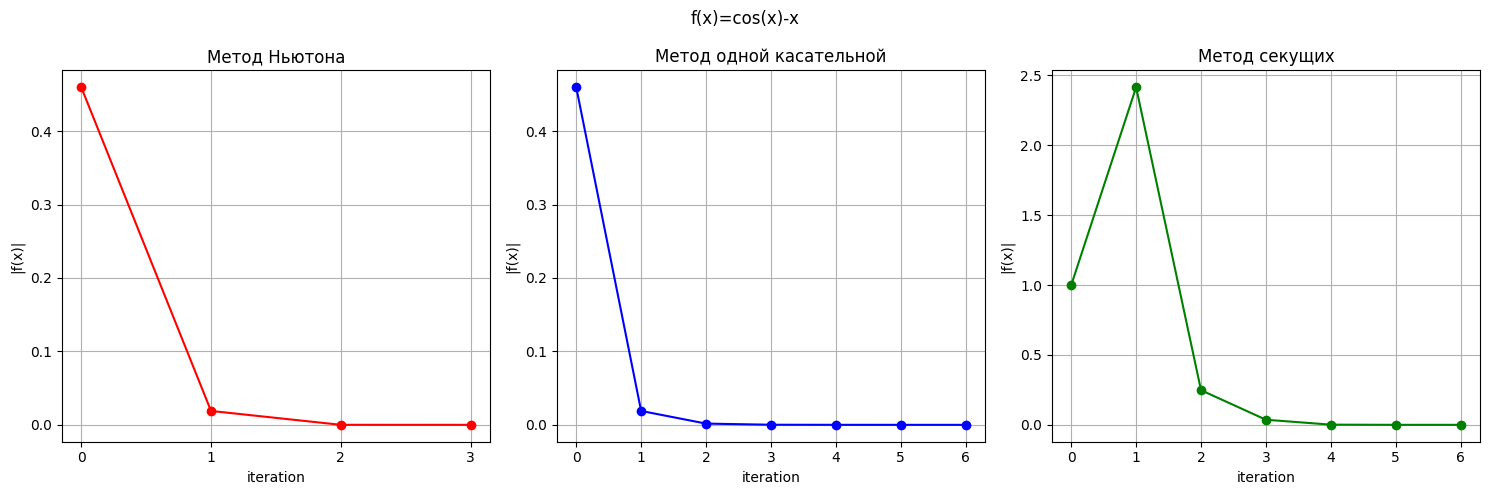

In [306]:
experiment_test(
    formula="f(x)=cos(x)-x",
    f = lambda x: np.cos(x) - x,
    df = lambda x: -np.sin(x) - 1,
    newton_x0 = 1,
    tangent_x0 = 1,
    secant_x0 = 1e-4,
    secant_x1 = 2
)

/tmp/ipython-input-1412486634.py:13: RuntimeWarning: overflow encountered in scalar divide
  x = x - f(x)/df_x0
/tmp/ipython-input-3989532054.py:3: RuntimeWarning: invalid value encountered in cos
  f = lambda x: np.cos(x) - x,


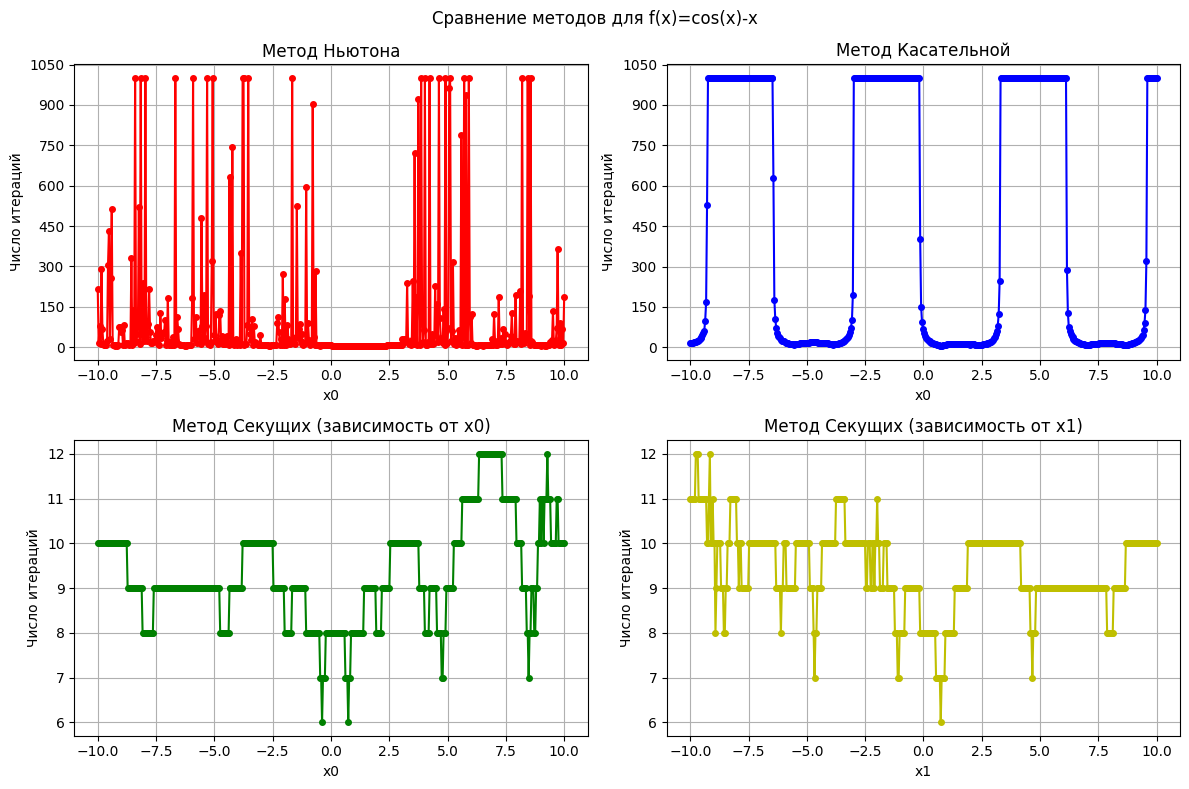

In [307]:
experiment_start(
    formula="f(x)=cos(x)-x",
    f = lambda x: np.cos(x) - x,
    df = lambda x: -np.sin(x) - 1,
    newton_x0_range = np.linspace(-10, 10, 500),
    tangent_x0_range = np.linspace(-10, 10, 500),
    secant_x0_range = np.linspace(-10, 10, 500),
    secant_x1 = 10.001,
    secant_x0 = -10.001,
    secant_x1_range = np.linspace(-10, 10, 500)
)

##### $f(x) = e^{-x} - x$

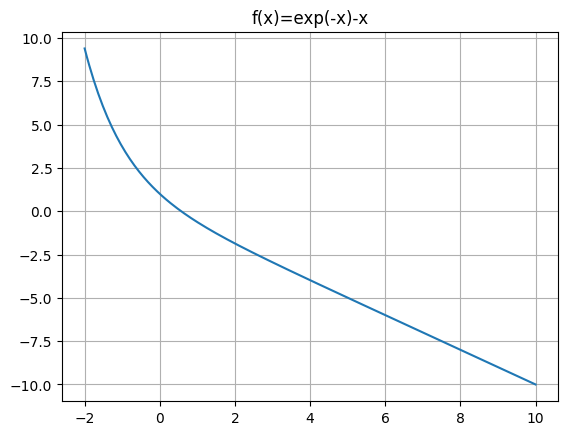

In [308]:
x = np.linspace(-2, 10, 200)
f = lambda x: np.exp(-x) - x
plt.plot(x, f(x))
plt.title("f(x)=exp(-x)-x")
plt.grid(True)
plt.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

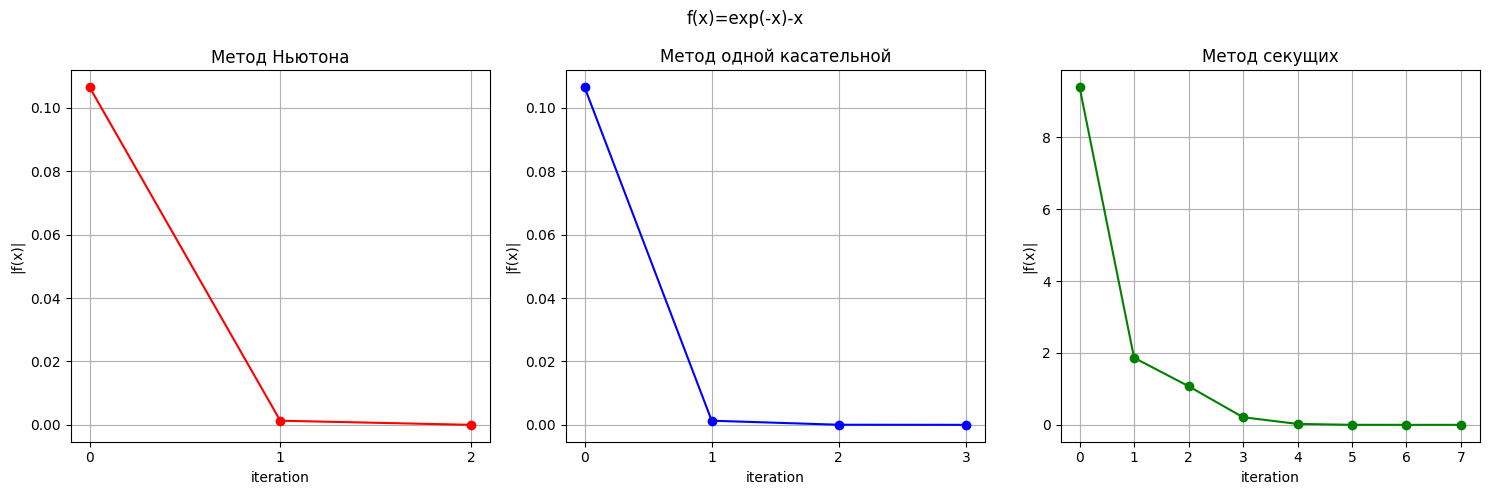

In [309]:
experiment_test(
    formula="f(x)=exp(-x)-x",
    f = lambda x: np.exp(-x) - x,
    df = lambda x: -np.exp(-x) - 1,
    newton_x0 = 0.5,
    tangent_x0 = 0.5,
    secant_x0 = -2,
    secant_x1 = 2,
)

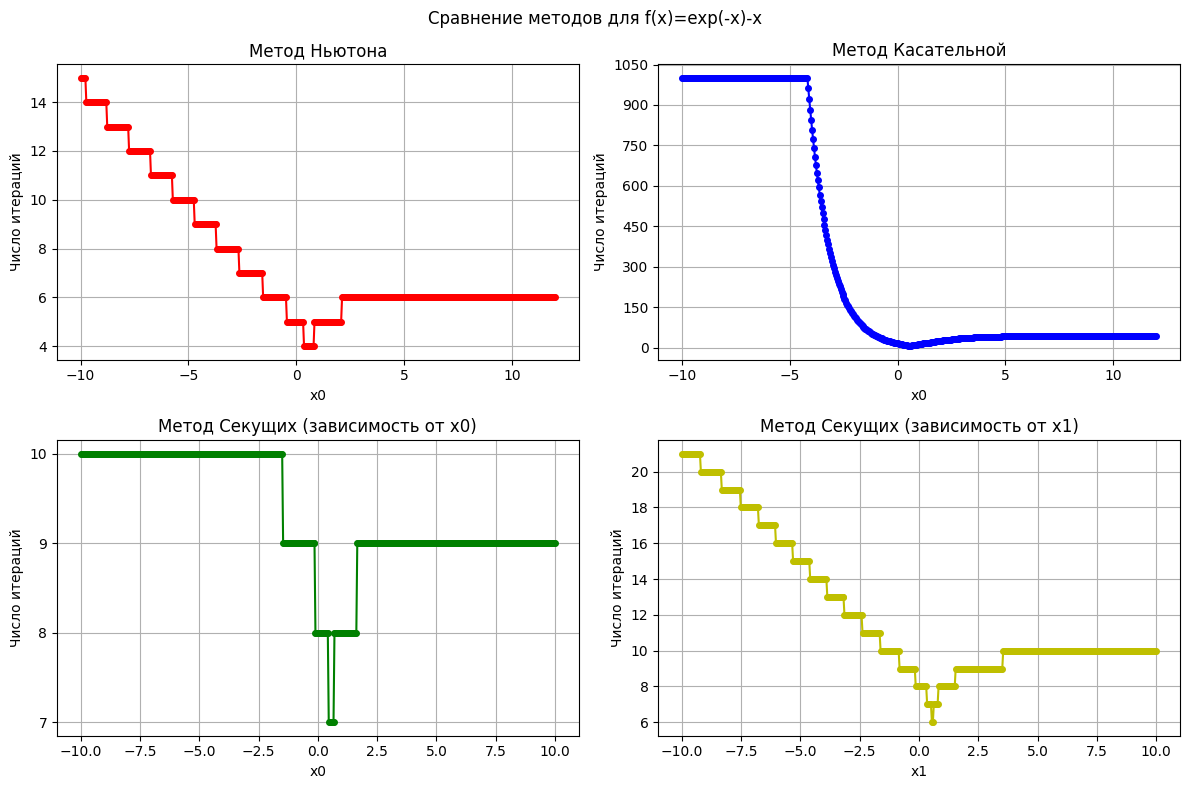

In [310]:
experiment_start(
    formula="f(x)=exp(-x)-x",
    f = lambda x: np.exp(-x) - x,
    df = lambda x: -np.exp(-x) - 1,
    newton_x0_range = np.linspace(-10, 12, 500),
    tangent_x0_range = np.linspace(-10, 12, 500),
    secant_x0_range = np.linspace(-10, 10, 500),
    secant_x1 = 10.001,
    secant_x0 = -10.001,
    secant_x1_range = np.linspace(-10, 10, 500)
)

# Нелинейные системы

##### Метод Ньютона

In [311]:
def multi_newton(x0, F, J, max_iter=10000, tol=1e-4, history=None):
  x = x0.copy()

  if history is not None: history.append(x.copy())

  for i in range(max_iter):
    F_val = np.array(F(*x)).flatten()
    J_val = np.array(J(*x))

    p = np.linalg.solve(J_val, F_val) # TODO: заменить на самописный метод
    x -= p

    if history: history.append(x.copy())

    if np.linalg.norm(F_val) < tol:
      return x

  print(f"Не сошёлся за {max_iter} итераций!")
  return x

##### Вывод истории

In [312]:
def display_history(history):
  iters = list(range(len(history)))
  hx = [history[i][0] for i in range(len(history))]
  hy = [history[i][1] for i in range(len(history))]

  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

  ax1.plot(iters, hx, 'ro-')
  ax1.set_title("Переменная x")
  ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax1.set_xlabel("Число итераций")
  ax1.grid(True)

  ax2.plot(iters, hy, 'bo-')
  ax2.set_title("Переменная y")
  ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax2.set_xlabel("Число итераций")
  ax2.grid(True)

  ax3.plot(hx, hy, 'go--')
  ax3.set_title("Точки (x, y)")
  ax3.set_xlabel("x")
  ax3.set_ylabel("y")
  ax3.grid(True)

  ax3.annotate('', xy=(hx[1], hy[1]), xytext=(hx[0], hy[0]),
               arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

  plt.tight_layout()
  plt.show()

##### Система (a)

$$
\begin{cases}
F_1(x, y) = \sin x + y^2 - 1 = 0,\\[6pt]
F_2(x, y) = x^2 - \cos y = 0.
\end{cases}
$$

###### Эталонные решения


|        x        |        y        |
| :-------------: | :-------------: |
| -0.569398449123 | -1.240614970431 |
| -0.569398449123 | +1.240614970431 |
| +0.953482427735 | -0.429608847958 |
| +0.953482427735 | +0.429608847958 |

###### Аналитическое (символьное) вычисление производных для Якобиан

In [313]:
x, y = sp.symbols('x y')

F = sp.Matrix([sp.sin(x) + y**2 - 1, x**2 - sp.cos(y)])

J = sp.Matrix([
  [sp.diff(F[0], x), sp.diff(F[0], y)],
  [sp.diff(F[1], x), sp.diff(F[1], y)]
])

display(Markdown("**Система уравнений F_a**"), F)
display(Markdown("**Матрица Якоби J_a**"), J)

F = sp.lambdify([x, y], F, 'numpy')
J = sp.lambdify([x, y], J, 'numpy')

**Система уравнений F_a**

Matrix([
[y**2 + sin(x) - 1],
[    x**2 - cos(y)]])

**Матрица Якоби J_a**

Matrix([
[cos(x),    2*y],
[   2*x, sin(y)]])

###### Тестирование

$x \approx 0.9534824277354988$

$y \approx 0.4296088479583021$

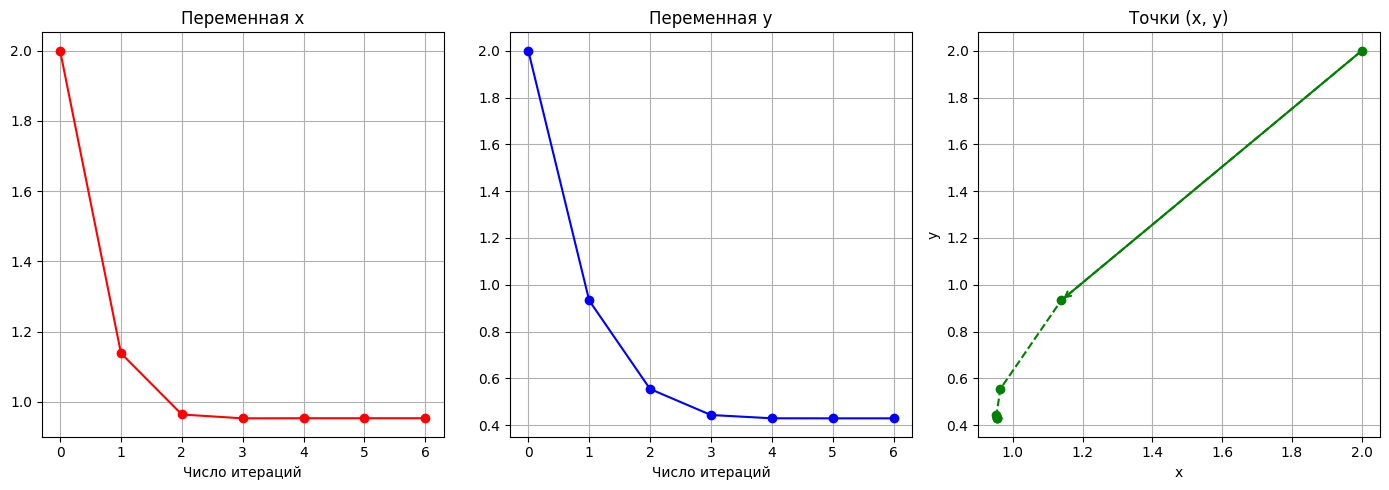

In [314]:
history = []
x = multi_newton(np.array([2, 2], float), F, J, history=history)

display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

###### Области сходимости

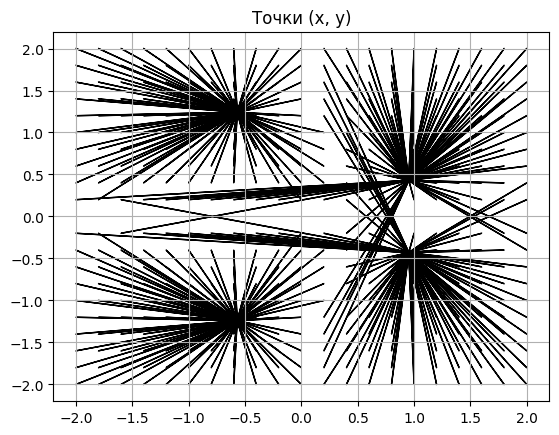

In [315]:
for x in np.linspace(-2, 2, 21):
  for y in np.linspace(-2, 2, 21):
    try:
      ax, ay = multi_newton(np.array([x, y], float), F, J)
      plt.arrow(x, y, ax-x, ay-y)

    except np.linalg.LinAlgError:
      continue

plt.title("Точки (x, y)")
plt.grid(True)
plt.show()

##### Система (б)

$$
\begin{cases}
F_1(x, y) = x^2 + y^2 - 4 = 0,\\[6pt]
F_2(x, y) = e^x + y - 1 = 0.
\end{cases}
$$

###### Эталонные решения
|        x        |         y       |
| :-------------: | :-------------: |
| -1.816264068825 | +0.837367799891 |
| +1.004168738475 | -1.729637287026 |

###### Аналитическое (символьное) вычисление производных для Якобиан

In [316]:
x, y = sp.symbols('x y')

F = sp.Matrix([x**2 + y**2 - 4, sp.exp(x) + y - 1])

J = sp.Matrix([
  [sp.diff(F[0], x), sp.diff(F[0], y)],
  [sp.diff(F[1], x), sp.diff(F[1], y)]
])

display(Markdown("**Система уравнений F_b**"), F)
display(Markdown("**Матрица Якоби J_b**"), J)

F = sp.lambdify([x, y], F, 'numpy')
J = sp.lambdify([x, y], J, 'numpy')

**Система уравнений F_b**

Matrix([
[x**2 + y**2 - 4],
[ y + exp(x) - 1]])

**Матрица Якоби J_b**

Matrix([
[   2*x, 2*y],
[exp(x),   1]])

###### Тестирование

$x \approx -1.8162640688341274$

$y \approx 0.837367799895369$

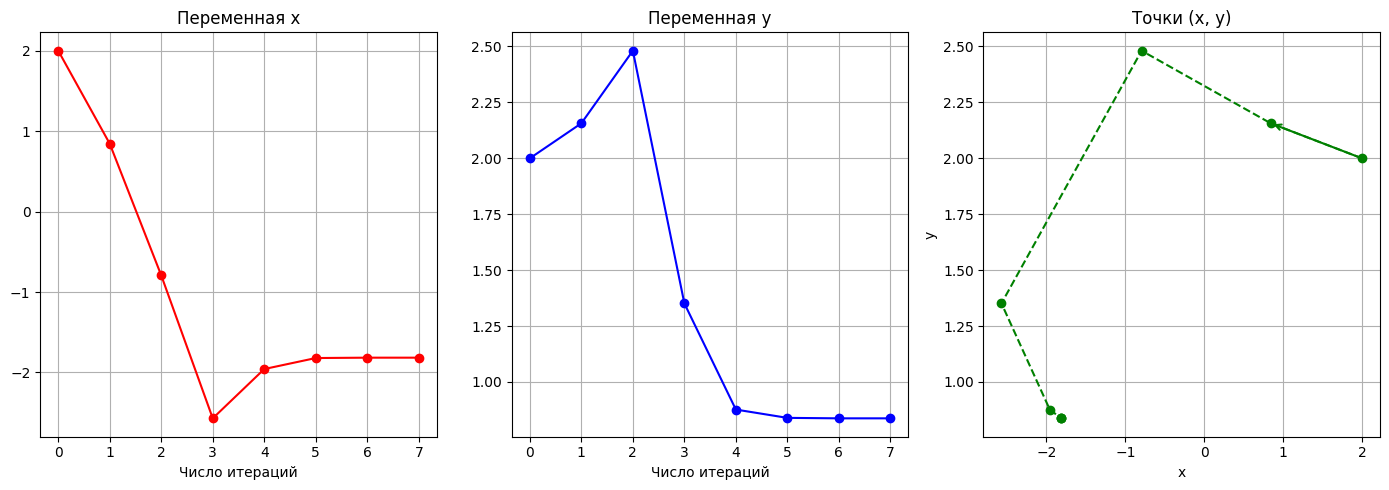

In [317]:
history = []
x = multi_newton(np.array([2, 2], float), F, J, history=history)

display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

###### Области сходимости

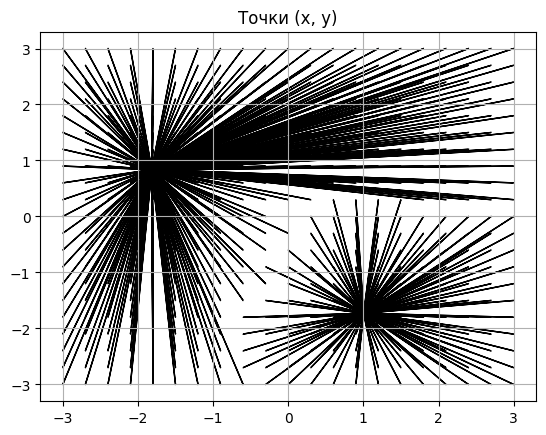

In [320]:
for x in np.linspace(-3, 3, 21):
  for y in np.linspace(-3, 3, 21):
    try:
      ax, ay = multi_newton(np.array([x, y], float), F, J)
      plt.arrow(x, y, ax-x, ay-y)

    except np.linalg.LinAlgError:
      continue

plt.title("Точки (x, y)")
plt.grid(True)
plt.show()

###### Исследование в точках $(-1, -1)$, $(0, 0)$, $(1, 1)$

В точке $(0, 0)$ Якобиан вырожден

$(x_0, y_0) = (-1, -1)$

$x \approx -1.8162640688251506$

$y \approx 0.8373677998912478$

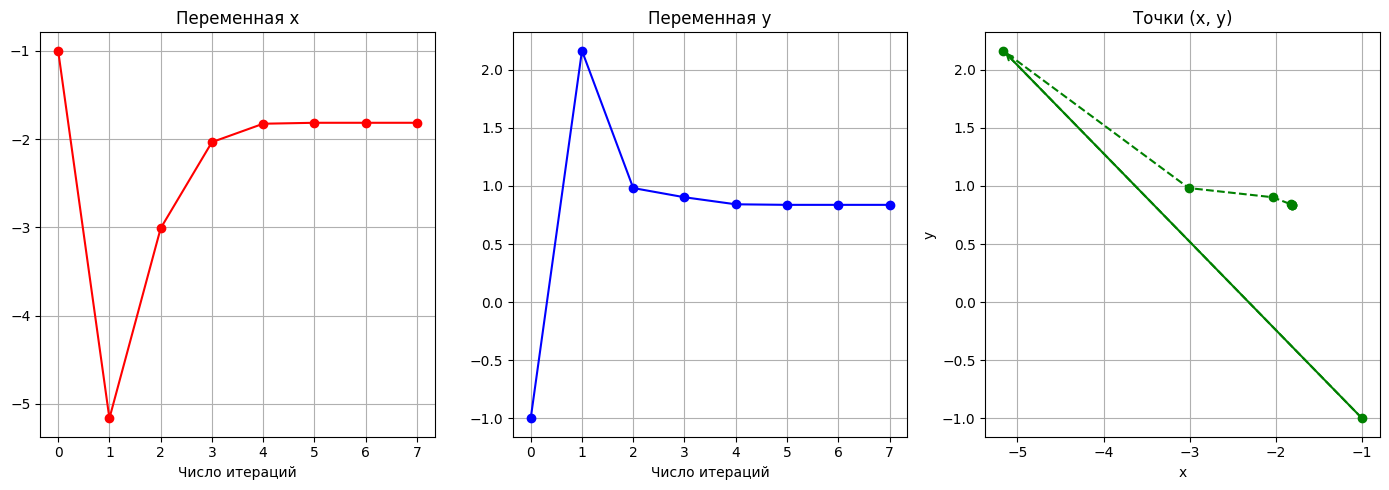

In [326]:
x_0, y_0 = -1, -1

history = []
x = multi_newton(np.array([x_0, y_0], float), F, J, history=history)

display(Markdown(f"$(x_0, y_0) = ({x_0}, {y_0})$"))
display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

$(x_0, y_0) = (1, 1)$

$x \approx -1.8162640688252372$

$y \approx 0.8373677998912874$

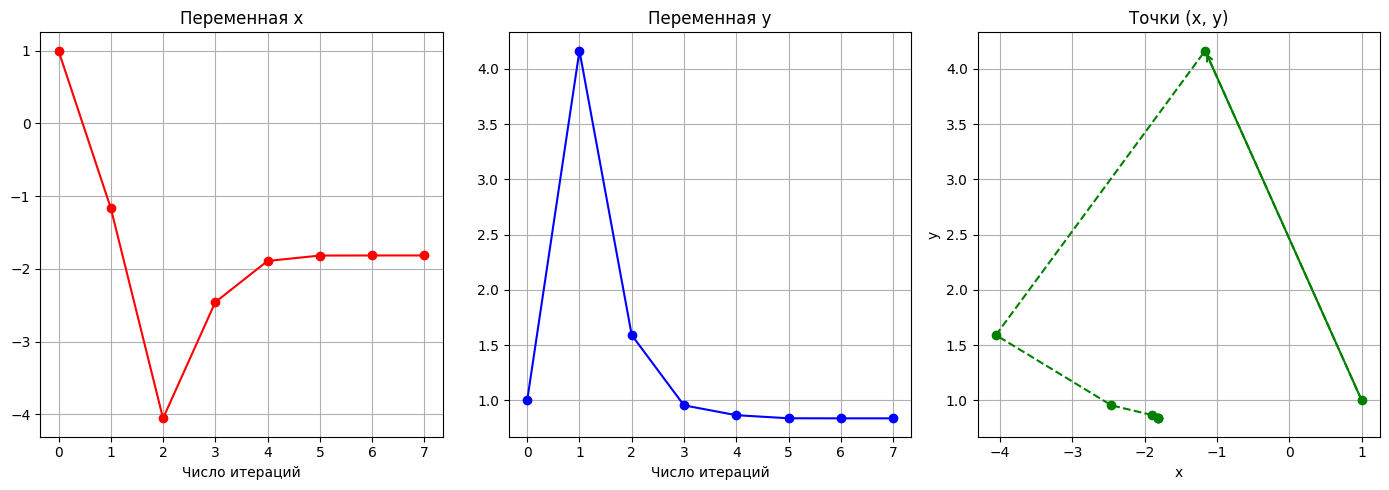

In [327]:
x_0, y_0 = 1, 1

history = []
x = multi_newton(np.array([x_0, y_0], float), F, J, history=history)

display(Markdown(f"$(x_0, y_0) = ({x_0}, {y_0})$"))
display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

$(x_0, y_0) = (1, -1)$

$x \approx 1.0041687384746592$

$y \approx -1.72963728702587$

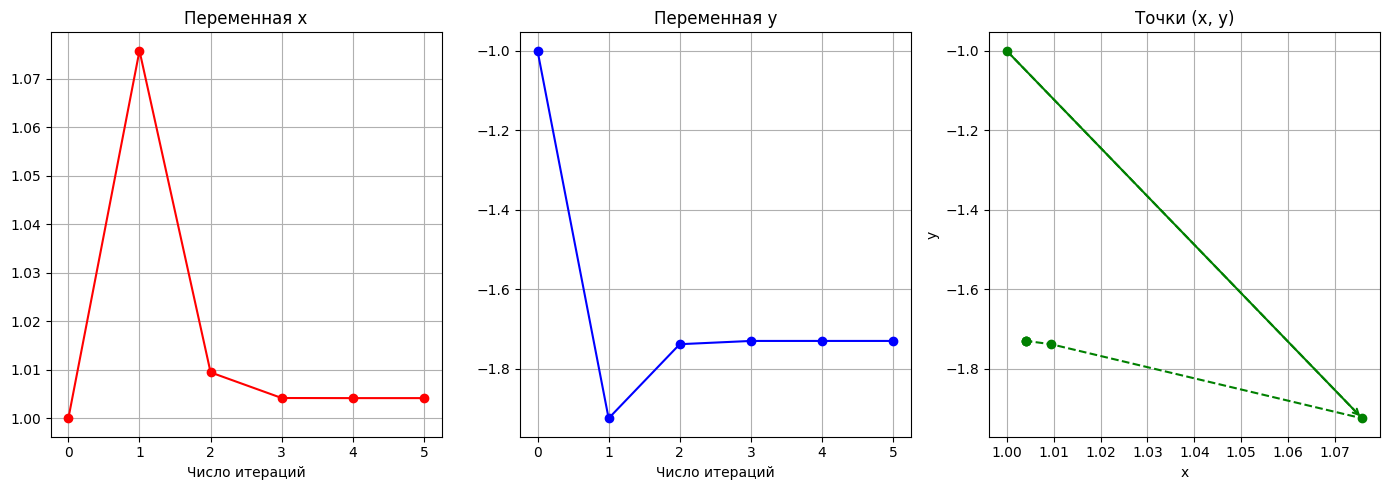

In [328]:
x_0, y_0 = 1, -1

history = []
x = multi_newton(np.array([x_0, y_0], float), F, J, history=history)

display(Markdown(f"$(x_0, y_0) = ({x_0}, {y_0})$"))
display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)